<a href="https://colab.research.google.com/github/laharik09/FUTURE_ML_01/blob/main/taskOne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [4]:
data = pd.read_excel("Online Retail.xlsx")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Dataset Info:")
data.info()

print("\nStatistical Summary:")
data.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Statistical Summary:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
print("Missing Values in Each Column:")
data.isnull().sum()

Missing Values in Each Column:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
data = data.dropna()

print("After Removing Missing Values:")
data.isnull().sum()

After Removing Missing Values:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [8]:
data = data[data['Quantity'] > 0]
data = data[data['UnitPrice'] > 0]

print("After Removing Negative Values:")
data[['Quantity', 'UnitPrice']].describe()

After Removing Negative Values:


,Quantity,UnitPrice
count,397884.000000,397884.000000
mean,12.988238,3.116488
std,179.331775,22.097877
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


In [9]:
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

print("TotalPrice Column Created ✅")
data[['Quantity', 'UnitPrice', 'TotalPrice']].head()

TotalPrice Column Created ✅


,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [10]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

print("Date Conversion Done")
data[['InvoiceDate']].head()

Date Conversion Done


,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [11]:
data['Year'] = data['InvoiceDate'].dt.year
data['Month'] = data['InvoiceDate'].dt.month
data['Day'] = data['InvoiceDate'].dt.day

print("Date Features Extracted")
data[['InvoiceDate','Year','Month','Day']].head()

Date Features Extracted


,InvoiceDate,Year,Month,Day
0,2010-12-01 08:26:00,2010,12,1
1,2010-12-01 08:26:00,2010,12,1
2,2010-12-01 08:26:00,2010,12,1
3,2010-12-01 08:26:00,2010,12,1
4,2010-12-01 08:26:00,2010,12,1


In [12]:
daily_sales = data.groupby(data['InvoiceDate'].dt.date)['TotalPrice'].sum()
daily_sales = daily_sales.reset_index()
daily_sales.columns = ['Date', 'Sales']

print("Daily Sales Data Prepared")
daily_sales.head()

Daily Sales Data Prepared


,Date,Sales
0,2010-12-01,46376.49
1,2010-12-02,47316.53
2,2010-12-03,23921.71
3,2010-12-05,31771.60
4,2010-12-06,31215.64


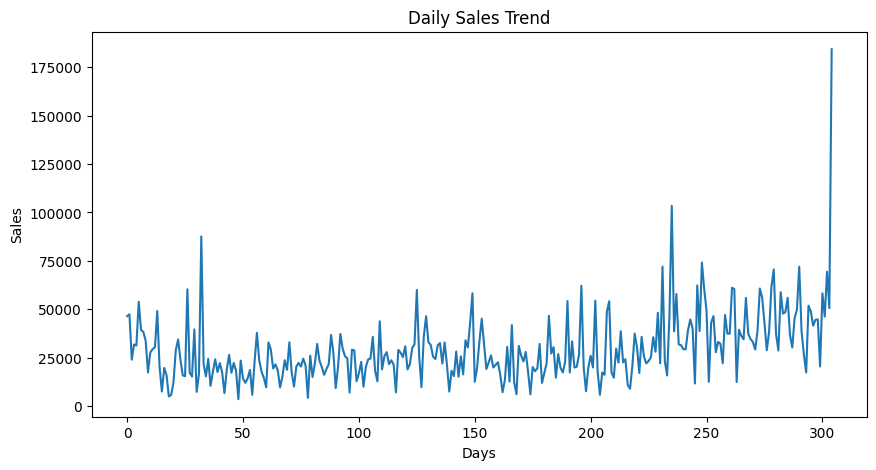

Sales Trend Visualization Done


In [13]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales['Sales'])
plt.title("Daily Sales Trend")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()

print("Sales Trend Visualization Done")

In [14]:
daily_sales['Days'] = np.arange(len(daily_sales))

X = daily_sales[['Days']]
y = daily_sales['Sales']

print("Model Input Prepared")
print("X sample:")
print(X.head())
print("y sample:")
print(y.head())

Model Input Prepared
X sample:
   Days
0     0
1     1
2     2
3     3
4     4
y sample:
0    46376.49
1    47316.53
2    23921.71
3    31771.60
4    31215.64
Name: Sales, dtype: float64


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Model Training Completed")

Model Training Completed


In [16]:
future_days = np.arange(len(daily_sales), len(daily_sales)+30).reshape(-1,1)
forecast = model.predict(future_days)

print("Future Predictions Generated")
print(forecast[:5])

Future Predictions Generated
[41714.07427601 41795.74972336 41877.4251707  41959.10061804
 42040.77606538]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


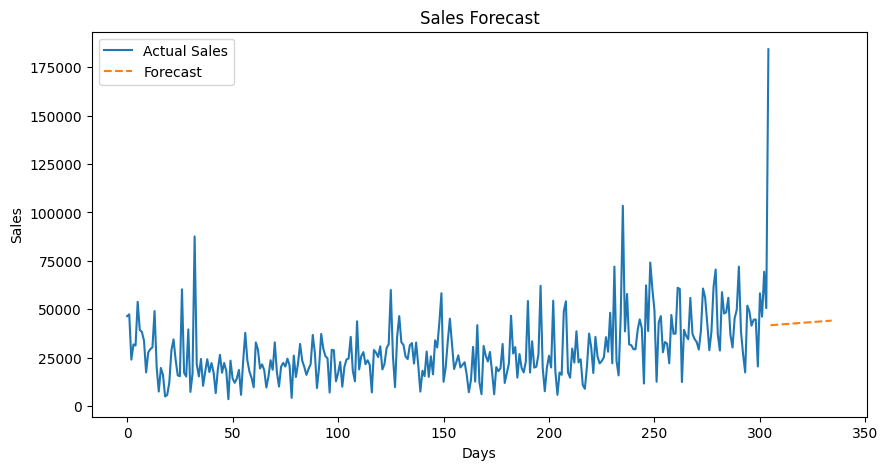

Forecast Visualization Done


In [17]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales['Sales'], label='Actual Sales')
plt.plot(range(len(daily_sales), len(daily_sales)+30), forecast, label='Forecast', linestyle='--')
plt.legend()
plt.title("Sales Forecast")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()

print("Forecast Visualization Done")

In [18]:
print("Top 5 Countries by Orders:")
print(data['Country'].value_counts().head())

print("\nTop 5 Products:")
print(data['Description'].value_counts().head())

Top 5 Countries by Orders:
Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Name: count, dtype: int64

Top 5 Products:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1723
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1396
Name: count, dtype: int64


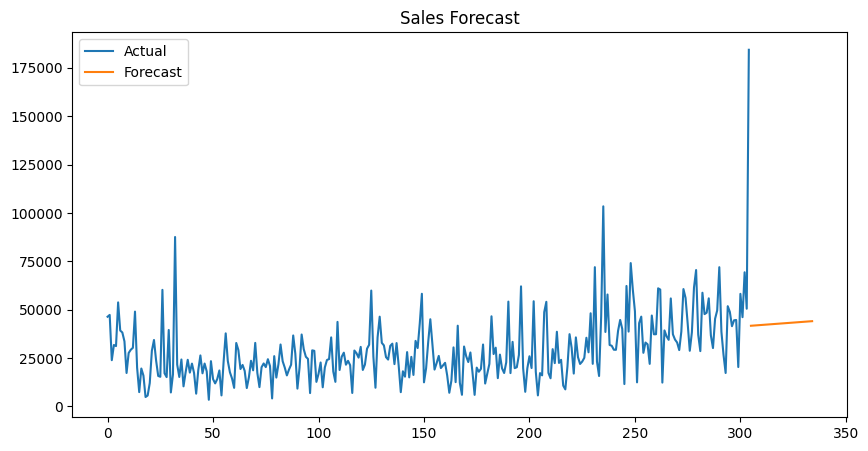

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales['Sales'], label='Actual')
plt.plot(range(len(daily_sales), len(daily_sales)+30), forecast, label='Forecast')
plt.legend()
plt.title("Sales Forecast")
plt.show()
plt.savefig("forecast.png")

In [21]:
print("Top Countries:")
print(data['Country'].value_counts().head())

Top Countries:
Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Name: count, dtype: int64
